# Airline Sentiment Analysis

Notebook عملي لتحليل مشاعر تغريدات شركات الطيران باستخدام `pandas`, `nltk` و`scikit-learn`.

**المسار:** تحميل الداتا → فحصها → تنظيف النص → حذف stopwords → TF-IDF → train/test split → Logistic Regression.

## 1) جهّز البيئة

شغّل الأمر التالي مرة واحدة في Terminal إذا كانت المكتبات غير مثبتة:

```bash
pip install pandas scikit-learn nltk matplotlib jupyter
jupyter notebook
```

In [1]:
import re
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from nltk.corpus import stopwords
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, ConfusionMatrixDisplay
from sklearn.model_selection import train_test_split

pd.set_option('display.max_colwidth', 120)

## 2) نزّل الداتاسة

نزّل `Tweets.csv` من [Kaggle](https://www.kaggle.com/datasets/crowdflower/twitter-airline-sentiment) وضعه في نفس فولدر هذا الـ notebook.

In [2]:
df = pd.read_csv('Tweets.csv')
print(f'Rows: {len(df):,} | Columns: {len(df.columns)}')
df.head()

Rows: 14,640 | Columns: 15


,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


## 3) شوف الداتا بنفسك

نطبع أول صفوف ونشوف عدد التغريدات في كل فئة.

,tweet_id,airline_sentiment,airline_sentiment_confidence,negativereason,negativereason_confidence,airline,airline_sentiment_gold,name,negativereason_gold,retweet_count,text,tweet_coord,tweet_created,tweet_location,user_timezone
0,570306133677760513,neutral,1.0000,NaN,NaN,Virgin America,NaN,cairdin,NaN,0,@VirginAmerica What @dhepburn said.,NaN,2015-02-24 11:35:52 -0800,NaN,Eastern Time (US & Canada)
1,570301130888122368,positive,0.3486,NaN,0.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica plus you've added commercials to the experience... tacky.,NaN,2015-02-24 11:15:59 -0800,NaN,Pacific Time (US & Canada)
2,570301083672813571,neutral,0.6837,NaN,NaN,Virgin America,NaN,yvonnalynn,NaN,0,@VirginAmerica I didn't today... Must mean I need to take another trip!,NaN,2015-02-24 11:15:48 -0800,Lets Play,Central Time (US & Canada)
3,570301031407624196,negative,1.0000,Bad Flight,0.7033,Virgin America,NaN,jnardino,NaN,0,"@VirginAmerica it's really aggressive to blast obnoxious ""entertainment"" in your guests' faces &amp; they have littl...",NaN,2015-02-24 11:15:36 -0800,NaN,Pacific Time (US & Canada)
4,570300817074462722,negative,1.0000,Can't Tell,1.0000,Virgin America,NaN,jnardino,NaN,0,@VirginAmerica and it's a really big bad thing about it,NaN,2015-02-24 11:14:45 -0800,NaN,Pacific Time (US & Canada)


,count
airline_sentiment,
negative,9178
neutral,3099
positive,2363


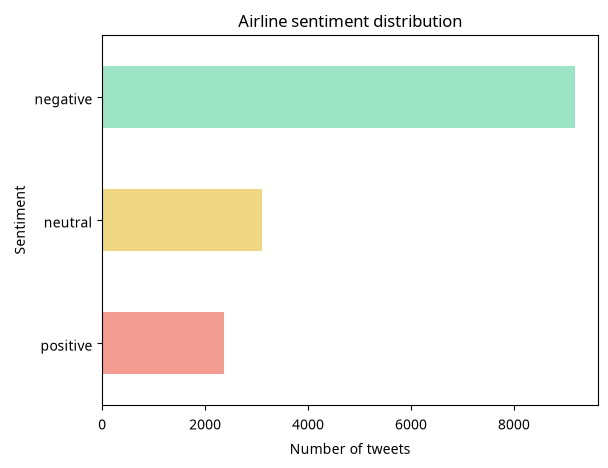

In [3]:
display(df.head())
sentiment_counts = df['airline_sentiment'].value_counts()
display(sentiment_counts.to_frame('count'))

sentiment_counts.sort_values().plot(kind='barh', color=['#f19b91', '#f0d783', '#9ce4c5'])
plt.title('Airline sentiment distribution')
plt.xlabel('Number of tweets')
plt.ylabel('Sentiment')
plt.show()

## 4) نظّف النص بنفسك

نحوّل النص لحروف صغيرة ونزيل الروابط والـ mentions. نحتفظ بباقي علامات الترقيم في هذه المرحلة حتى نرى الفرق بوضوح.

In [4]:
def clean_text(text):
    text = str(text).lower()
    text = re.sub(r'http\S+', '', text)
    text = re.sub(r'@\w+', '', text)
    return text.strip()

df['clean_text'] = df['text'].apply(clean_text)

for before, after in zip(df['text'].head(3), df['clean_text'].head(3)):
    print('BEFORE:', before)
    print('AFTER :', after)
    print('-' * 80)

BEFORE: @VirginAmerica What @dhepburn said.
AFTER : what  said.
--------------------------------------------------------------------------------
BEFORE: @VirginAmerica plus you've added commercials to the experience... tacky.
AFTER : plus you've added commercials to the experience... tacky.
--------------------------------------------------------------------------------
BEFORE: @VirginAmerica I didn't today... Must mean I need to take another trip!
AFTER : i didn't today... must mean i need to take another trip!
--------------------------------------------------------------------------------


## 5) احذف stopwords مع الحفاظ على `not` و`no`

In [5]:
import nltk
nltk.download('stopwords')

stop_words = set(stopwords.words('english')) - {'not', 'no'}

def remove_stopwords(text):
    words = text.split()
    return ' '.join(word for word in words if word not in stop_words)

df['clean_text'] = df['clean_text'].apply(remove_stopwords)
print('قبل حذف stopwords:')
print('this is not a good flight')
print('بعد حذف stopwords مع الحفاظ على not/no:')
print(remove_stopwords('this is not a good flight'))

قبل حذف stopwords:
this is not a good flight
بعد حذف stopwords مع الحفاظ على not/no:
not good flight


[nltk_data] Downloading package stopwords to /home/ubuntu/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


## 6) حوّل النص لأرقام باستخدام TF-IDF

نستخدم unigram وbigram ونحتفظ بأهم 5,000 ميزة.

In [6]:
vectorizer = TfidfVectorizer(max_features=5000, ngram_range=(1, 2))
X = vectorizer.fit_transform(df['clean_text'])
y = df['airline_sentiment']

print('X shape:', X.shape)
print('First 10 feature names:', vectorizer.get_feature_names_out()[:10])
print('First row, first 10 TF-IDF values:', X[0, :10].toarray())

X shape: (14640, 5000)
First 10 feature names: ['00' '000' '000 miles' '00pm' '02' '03' '05' '10' '10 000' '10 24']
First row, first 10 TF-IDF values: [[0. 0. 0. 0. 0. 0. 0. 0. 0. 0.]]


## 7) قسّم train / test

`stratify` يحافظ على نفس نسبة الفئات في مجموعتي التدريب والاختبار.

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print('X_train:', X_train.shape)
print('X_test :', X_test.shape)

X_train: (11712, 5000)
X_test : (2928, 5000)


## 8) درّب Logistic Regression

لو ظهر `ConvergenceWarning`، غيّر `max_iter` إلى `2000`.

Test accuracy: 0.789
              precision    recall  f1-score   support

    negative       0.81      0.94      0.87      1835
     neutral       0.67      0.50      0.57       620
    positive       0.83      0.57      0.68       473

    accuracy                           0.79      2928
   macro avg       0.77      0.67      0.71      2928
weighted avg       0.78      0.79      0.78      2928



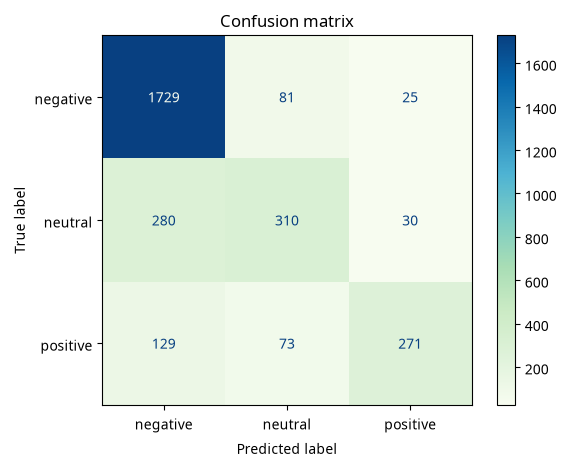

In [8]:
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

predictions = model.predict(X_test)
print(f'Test accuracy: {accuracy_score(y_test, predictions):.3f}')
print(classification_report(y_test, predictions))

ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap='GnBu')
plt.title('Confusion matrix')
plt.show()

## جرّب تنبؤًا جديدًا

استخدم نفس `vectorizer` ثم مرّر النص للموديل.

In [9]:
new_tweet = 'I had a great flight and the crew was amazing!'
new_tweet_clean = remove_stopwords(clean_text(new_tweet))
new_tweet_vector = vectorizer.transform([new_tweet_clean])
print('Prediction:', model.predict(new_tweet_vector)[0])

Prediction: positive
